In [8]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### ***PHASE 1. Model Evaluation***

In [ ]:
# 1. Load model and data
df = pd.read_parquet('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/data/03.cleaned/multi_appliances_cleaned_engineered.parquet')
pipeline = joblib.load('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/models/saved_models/multi_category_xgb_pipeline.pkl')

print(type(pipeline))

# Read the splitted data 
# Load the fixed splits
X_train = pd.read_parquet('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/models/dataset/X_train.parquet')
X_test = pd.read_parquet('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/models/dataset/X_test.parquet')
y_train = pd.read_parquet('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/models/dataset/y_train.parquet').squeeze() # squeeze() turns 1-col DF back to Series
y_test = pd.read_parquet('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/models/dataset/y_test.parquet').squeeze()

# Universal features
categorical_cols = ['category']

# 2. Generate predictions for X_train and X_test
y_train_pred = np.expm1(pipeline.predict(X_train))
y_test_pred = np.expm1(pipeline.predict(X_test))
y_train_true = np.expm1(y_train)
y_test_true = np.expm1(y_test)

# 3. Calculate metrics for both sets
def calculate_metrics(y_true,y_pred):
    return {
        'R2': r2_score(y_true,y_pred),
        'MAE':mean_absolute_error(y_true,y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true,y_pred)),
        'MAPE':mean_absolute_percentage_error(y_true,y_pred)
    }

# 4. Create the comparison table

metrics_df = pd.DataFrame({
    'Train':calculate_metrics(y_train_true,y_train_pred),
    'Test':calculate_metrics(y_test_true,y_test_pred)
})

print(metrics_df)

<class 'sklearn.pipeline.Pipeline'>
            Train         Test
R2       0.929039     0.883387
MAE   2785.567777  3481.804930
RMSE  4566.783400  5821.000506
MAPE     0.083223     0.110851


### ***1.2: Predicted VS Actual Plot***

- The metrics table (MAE, RMSE) tells us how much the model is off, but it doesn't tell us where it is off. A "Predicted vs Actual" scatter plot is the most intuitive way to see:

- The General Trend: Do the points follow the 45-degree line?
- Saturation: Does the model struggle with very cheap or very expensive products?
- Outliers: Are there points far away from the line (the "big misses" that caused the RMSE to be higher than the MAE)?

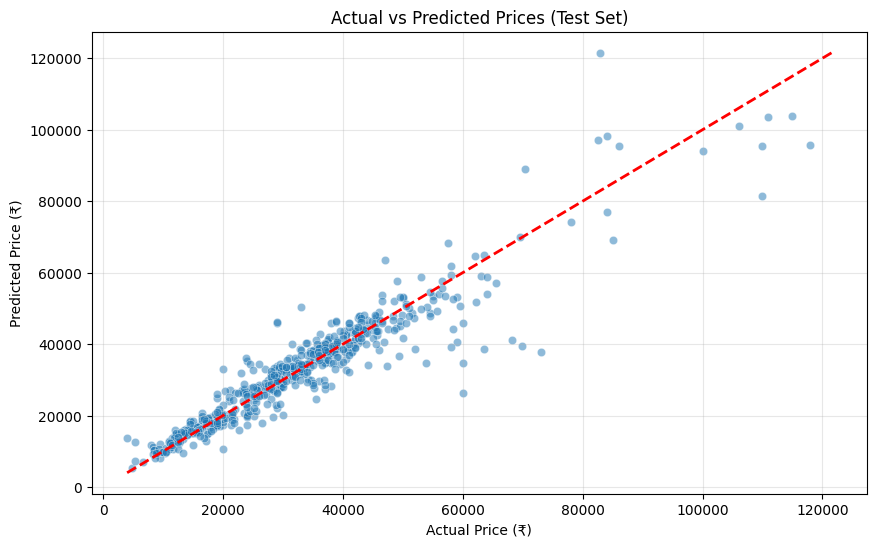

In [11]:
# 2. Generate Predictions (converting from log scale)
y_pred = np.expm1(pipeline.predict(X_test))
y_true = np.expm1(y_test)

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_true , y=y_pred , alpha=0.5)

# Add the 45-degree reference line
max_val = max(max(y_true), max(y_pred))
min_val = min(min(y_true), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--')

plt.title('Actual vs Predicted Prices (Test Set)')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.grid(True, alpha=0.3)
plt.show()


- Most of the predictions are fairly close to the actual prices (Mostly Non-premium Appliances.)
- Model underestimates the high-end premium products.
- And Model overestimates the low-ned budget products.
- There are a few random outliers too.

- Analyzed the scatter plot and discovered that the model struggles with the extremes of the price range. This told me that the model is conservative and tends to predict closer to the average price."

### ***1.3: Residual Diagnostics***

**1. Residual VS Predicted**
- 1. Check if Residual VS Predicted curve follow a specific pattern
- 2. To check if the errors are normally distributed.
- 3. To check if the residuals are normally distributed.

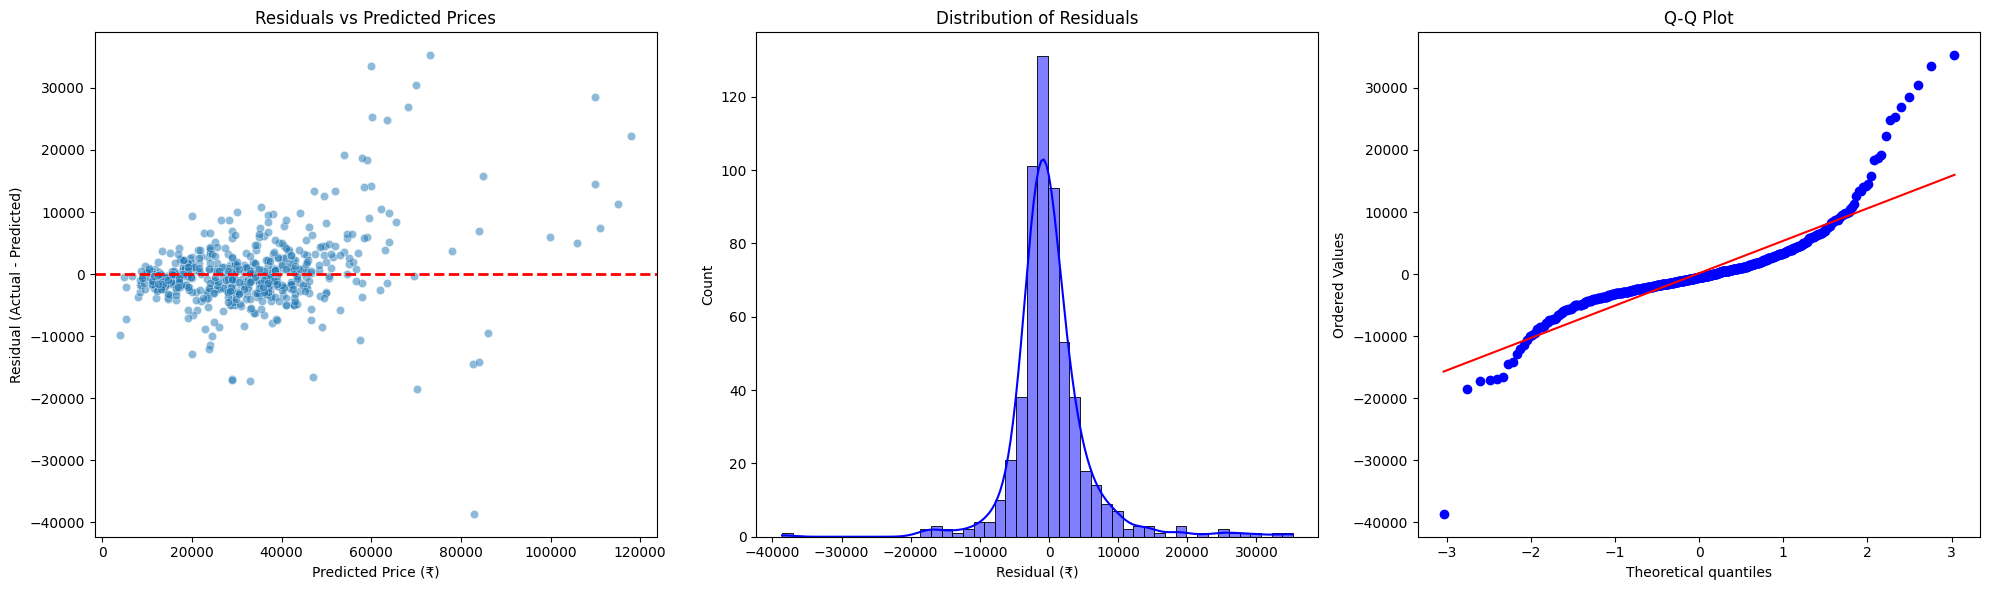

In [14]:
residuals = y_true - y_pred

fig,ax = plt.subplots(1,3,figsize=(20,6))

# Plot 1 Residual Vs Predicted
sns.scatterplot(x=y_true , y=residuals , alpha=0.5 , ax=ax[0])
ax[0].axhline(y=0, color='red', linestyle='--', lw=2)
ax[0].set_title('Residuals vs Predicted Prices')
ax[0].set_xlabel('Predicted Price (₹)')
ax[0].set_ylabel('Residual (Actual - Predicted)')

# Plot 2. Histogram + Kde On residuals

sns.histplot(x = residuals, kde=True , ax=ax[1] , color='blue')
ax[1].set_title('Distribution of Residuals')
ax[1].set_xlabel('Residual (₹)')

# Plot 3. Q-Q Plot 
import scipy.stats as stats
stats.probplot(residuals , dist='norm' , plot = ax[2])
ax[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/outputs/residual_diagnostics.png')
plt.show()





**1. Residuals vs Predicted Prices**
- What we expect ideally:
- Residuals should be randomly scattered around 0.
- The spread should remain roughly constant across all predicted values.
- No obvious pattern should be visible.

**What your plot shows:**
- **Good Signs**
Residuals are centered around the zero line.
No strong curved pattern is visible.
This suggests the model captures the main relationship reasonably well.
**Issues Observed**

Heteroscedasticity
The residual spread increases as predicted prices increase.
Predictions below ₹40,000 have relatively small errors.
Predictions above ₹60,000 show much larger errors.

***This means:***

The model predicts cheaper appliances more accurately than expensive appliances.

**What your histogram shows**
**Good Signs**
Residuals are centered close to zero.
Most errors are small.
Majority of predictions deviate only by a few thousand rupees.
**Issues Observed**
- Heavy Tails

The distribution has long tails on both sides.

**This means:**

Large prediction errors occur more frequently than expected under normality.

**What your Q–Q plot shows**
**Good Signs**
Middle quantiles align reasonably well with the reference line.
Most observations behave approximately normally.
**Issues Observed**
Strong Deviations at Both Ends

The tails bend away from the line.

### ***1.4: Error Segmentation Analysis***

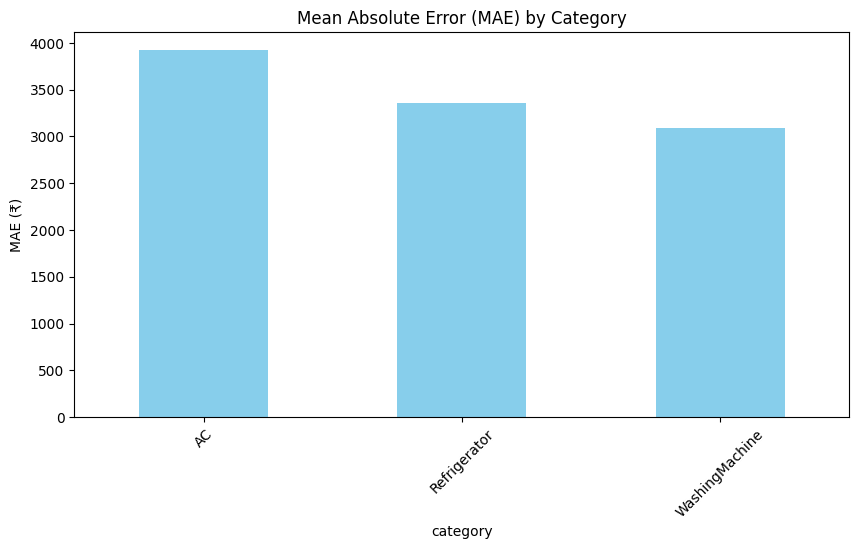

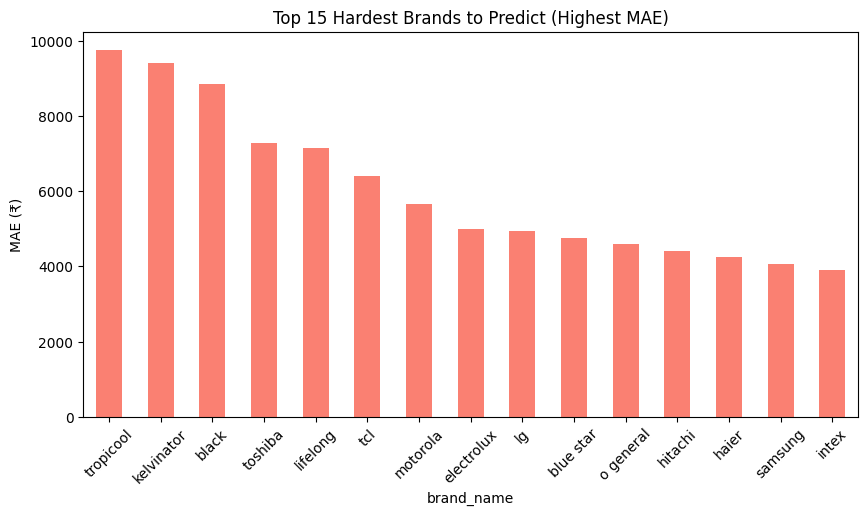

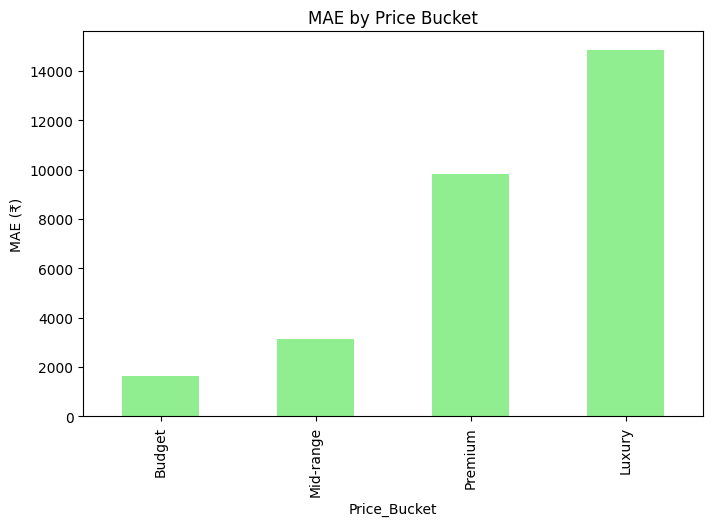


Price Bucket MAE:
 Price_Bucket
Budget        1622.647897
Mid-range     3126.105283
Premium       9811.403774
Luxury       14850.782552
Name: Absolute_Error, dtype: float64


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Merge predictions back into a DataFrame for analysis
# Note: Use X_test and y_true (original scale)
analysis_df = X_test.copy()
analysis_df['Actual_Price'] = y_true
analysis_df['Predicted_Price'] = y_pred
analysis_df['Absolute_Error'] = np.abs(analysis_df['Actual_Price'] - analysis_df['Predicted_Price'])

# --- Analysis A: Category-wise MAE ---
cat_mae = analysis_df.groupby('category')['Absolute_Error'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
cat_mae.plot(kind='bar', color='skyblue')
plt.title('Mean Absolute Error (MAE) by Category')
plt.ylabel('MAE (₹)')
plt.xticks(rotation=45)
plt.show()

# --- Analysis B: Brand-wise MAE (Top 15) ---
# Assuming 'brand' is a column in X_test. If target encoded, use original brand names.
# If you have the original brand names, use them here:
brand_mae = analysis_df.groupby('brand_name')['Absolute_Error'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 5))
brand_mae.plot(kind='bar', color='salmon')
plt.title('Top 15 Hardest Brands to Predict (Highest MAE)')
plt.ylabel('MAE (₹)')
plt.xticks(rotation=45)
plt.show()

# --- Analysis C: Price Bucket Error ---
# Define buckets based on your dataset's price range
bins = [0, 20000, 50000, 100000, np.inf]
labels = ['Budget', 'Mid-range', 'Premium', 'Luxury']
analysis_df['Price_Bucket'] = pd.cut(analysis_df['Actual_Price'], bins=bins, labels=labels)

bucket_mae = analysis_df.groupby('Price_Bucket', observed=True)['Absolute_Error'].mean()
plt.figure(figsize=(8, 5))
bucket_mae.plot(kind='bar', color='lightgreen')
plt.title('MAE by Price Bucket')
plt.ylabel('MAE (₹)')
plt.show()

print("\nPrice Bucket MAE:\n", bucket_mae)

"The model exhibits strong price-dependent variance. While the MAE for budget products is low, the error grows exponentially for luxury products. This indicates that the features used (like capacity or energy rating) are primary drivers for budget prices, but luxury prices are likely driven by factors not captured in the dataset, such as brand prestige, luxury materials, or exclusive features."

### ***1.5 - Edge Case Investigation***

In [19]:
# 1. Identify the top 20 largest absolute errors
top_errors = analysis_df.nlargest(20, 'Absolute_Error')

# 2. Select key columns for investigation to avoid a cluttered table
# Include: Brand, Category, Actual Price, Predicted Price, Absolute Error, and any key specs
cols_to_show = ['brand_name', 'category', 'Actual_Price', 'Predicted_Price', 'Absolute_Error']
# Add a few spec columns if you have them (e.g., 'capacity', 'energy_rating') 
# to see WHY it might have failed.

print("Top 20 Largest Prediction Errors:")
display(top_errors[cols_to_show])

# 3. Calculation for "Percentage Error" for these top 20
top_errors['Percentage_Error'] = (top_errors['Absolute_Error'] / top_errors['Actual_Price']) * 100
print("\nPercentage Error for Top 20 Failures:")
display(top_errors[['brand_name', 'category', 'Percentage_Error']])

Top 20 Largest Prediction Errors:


,brand_name,category,Actual_Price,Predicted_Price,Absolute_Error
1081,haier,Refrigerator,82925.0,121534.890625,38609.890625
576,lg,AC,73022.0,37773.609375,35248.390625
2579,ifb,WashingMachine,59990.0,26427.935547,33562.064453
706,blue star,AC,69900.0,39458.109375,30441.890625
1749,haier,Refrigerator,109990.0,81420.914062,28569.085937
423,motorola,AC,68199.0,41220.125000,26978.875000
469,lg,AC,60055.0,34727.753906,25327.246094
781,samsung,AC,63490.0,38632.621094,24857.378906
1343,samsung,Refrigerator,117990.0,95739.398438,22250.601562
472,panasonic,AC,53900.0,34656.914062,19243.085937



Percentage Error for Top 20 Failures:


,brand_name,category,Percentage_Error
1081,haier,Refrigerator,46.560013
576,lg,AC,48.270919
2579,ifb,WashingMachine,55.946098
706,blue star,AC,43.550630
1749,haier,Refrigerator,25.974258
423,motorola,AC,39.559048
469,lg,AC,42.173418
781,samsung,AC,39.151644
1343,samsung,Refrigerator,18.858040
472,panasonic,AC,35.701458


- These errors are mostly due to Premium product prices which our model cannot predict, as it is not trained on premium products data much.
- Top brands like LG, Haier, Samsung appear more than 2-3 times and same with
- lower priced brands, for which our model over predicted.